# Column masking: a bat on an island

A bat flies on a small island inside a larger 10 x 10 m square. The recording
arena covers the whole square, but the animal only visits a compact part of it.

A 2-D B-spline basis built on the full square therefore has many columns that no
observation ever activates. Those columns are empty. The data do not directly
constrain those coefficients. Dropping them reduces the coefficient space
and changes the penalty model, so predictions and selected smoothing
parameters can differ from an unmasked fit.

This notebook shows how to:

1. Measure how many basis columns the data activate.
2. Fit a Poisson GAM with `drop_empty_columns=True`.
3. Read the mask back from `gam.component_infos_`.
4. Reconstruct the full 2-D tuning map, including the unvisited region.

This is the `pgam_jax` version of `island_col_mask_demo.ipynb` in the legacy
PGAM repository. The API is different. Legacy PGAM builds the mask by hand with
`get_active_col_mask()` and passes it as `col_mask=` to `add_smooth`. Here
masking is one constructor flag, and the model detects the empty columns during
`fit`.

## Imports

In [ ]:
import time

import jax
import matplotlib.pyplot as plt
import nemos as nmo
import numpy as np
import seaborn as sns
from matplotlib.patches import Circle

from pgam_jax import GAM

jax.config.update("jax_enable_x64", True)
sns.set_theme(style="whitegrid")

## 1. Simulate the bat trajectory

The island is a circle of radius 2.5 m centered at (6, 5) inside a 10 x 10 m
square. We draw 8000 positions uniformly from that disc.

In [2]:
rng = np.random.default_rng(42)

SQUARE = 10.0  # arena side length [m]
ISLAND_CENTER = np.array([6.0, 5.0])
ISLAND_RADIUS = 2.5  # [m]
N_POSITIONS = 8000

# Uniform sampling from a disc needs the square root of the radial variable.
radius = ISLAND_RADIUS * np.sqrt(rng.uniform(0.0, 1.0, N_POSITIONS))
angle = rng.uniform(0.0, 2 * np.pi, N_POSITIONS)
x_bat = ISLAND_CENTER[0] + radius * np.cos(angle)
y_bat = ISLAND_CENTER[1] + radius * np.sin(angle)

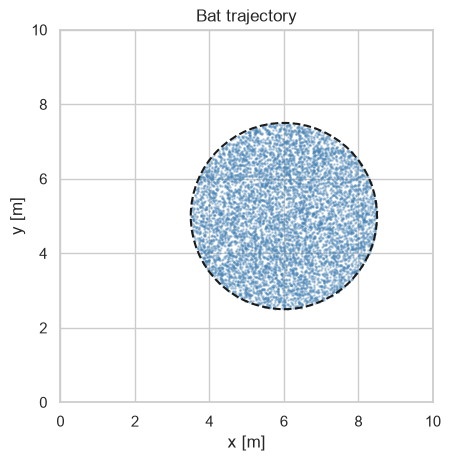

In [3]:
fig, ax = plt.subplots(figsize=(4.5, 4.5), constrained_layout=True)

ax.scatter(x_bat, y_bat, s=1, alpha=0.3, color="steelblue")
ax.add_patch(Circle(ISLAND_CENTER, ISLAND_RADIUS, fill=False, color="k", lw=1.5, ls="--"))
ax.set(
    xlim=(0, SQUARE),
    ylim=(0, SQUARE),
    title="Bat trajectory",
    xlabel="x [m]",
    ylabel="y [m]",
)
ax.set_aspect("equal")

## 2. Build the 2-D basis and count the active columns

The basis is a product of two 1-D B-spline bases over the whole square. In
`pgam_jax` a tensor-product smooth is a product of two `nemos` bases, and `GAM`
receives the two covariates as a tuple.

A column is empty when no row of the design matrix has a non-zero entry in it.
We can count that directly from `compute_features`, before fitting anything.

In [4]:
N_BASIS = 17

basis_1d = nmo.basis.BSplineEval(N_BASIS, bounds=(0.0, SQUARE))
basis = basis_1d * basis_1d

design_full = np.asarray(basis.compute_features(x_bat, y_bat))
observations_per_column = np.sum(np.abs(design_full) > 0, axis=0)
active = observations_per_column > 0

n_columns = design_full.shape[1]
n_active = int(active.sum())

print(f"Full basis columns : {n_columns}")
print(f"Active columns     : {n_active}  ({100 * n_active / n_columns:.0f} %)")
print(f"Empty columns      : {n_columns - n_active}")

Full basis columns : 289
Active columns     : 111  (38 %)
Empty columns      : 178


The tensor-product columns are ordered row-major, with the first covariate as
the outer index. Column `i * N_BASIS + j` is the product of basis function `i`
of x and basis function `j` of y. We can therefore reshape the mask into a
N_BASIS x N_BASIS grid and look at it.

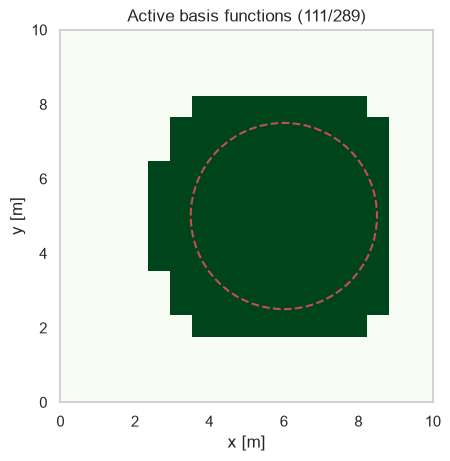

In [5]:
# Transpose so that x runs along the horizontal axis of the image.
active_grid = active.reshape(N_BASIS, N_BASIS).T

fig, ax = plt.subplots(figsize=(4.5, 4.5), constrained_layout=True)

ax.imshow(
    active_grid,
    origin="lower",
    extent=[0, SQUARE, 0, SQUARE],
    cmap="Greens",
    vmin=0,
    vmax=1,
    aspect="equal",
)
ax.add_patch(Circle(ISLAND_CENTER, ISLAND_RADIUS, fill=False, color="r", lw=1.5, ls="--"))
ax.set(
    title=f"Active basis functions ({n_active}/{n_columns})",
    xlabel="x [m]",
    ylabel="y [m]",
)
ax.grid(False)

Note one difference from the legacy notebook. Legacy PGAM always keeps the very
last column of the tensor product, so that its `X[:, :-1]` identifiability slice
keeps working. That corner cell always looks active there, even with no data in
it.

`pgam_jax` has no such exception. The mask covers the full basis width, and the
identifiability column comes off the surviving columns afterwards.

## 3. Simulate a known 2-D tuning function

The true log-rate is a 2-D Gaussian bump near the center of the island. Spike
counts come from a Poisson distribution.

In [6]:
PEAK_LOG_RATE = 2.0  # log-rate added at the peak
TUNING_WIDTH = 1.5  # [m]
BACKGROUND_LOG_RATE = -1.5
PEAK_CENTER = np.array([5.5, 5.0])


def true_log_rate(x, y):
    """Ground-truth log-rate: a Gaussian bump on the island."""
    squared_distance = ((x - PEAK_CENTER[0]) / TUNING_WIDTH) ** 2 + ((y - PEAK_CENTER[1]) / TUNING_WIDTH) ** 2
    return BACKGROUND_LOG_RATE + PEAK_LOG_RATE * np.exp(-0.5 * squared_distance)


log_rate_bat = true_log_rate(x_bat, y_bat)
spike_counts = rng.poisson(np.exp(log_rate_bat)).astype(float)

print(f"Mean spike count per bin: {spike_counts.mean():.3f}")

Mean spike count per bin: 0.726


## 4. Fit with and without masking

`drop_empty_columns=True` drops a column that has no non-zero entry. An integer
instead sets a minimum observation count per column, for example
`drop_empty_columns=20`.

We fit both models, so that we can compare them.

In [7]:
inputs = (x_bat, y_bat)
method = "pql_gcv"

start = time.perf_counter()
gam_masked = GAM(basis, method=method, drop_empty_columns=True, use_scipy=True)
gam_masked.fit(inputs, spike_counts)
masked_seconds = time.perf_counter() - start

start = time.perf_counter()
gam_full = GAM(basis, method=method, drop_empty_columns=False, use_scipy=True)
gam_full.fit(inputs, spike_counts)
full_seconds = time.perf_counter() - start

After the fit, `gam.component_infos_` holds one layout record per basis
component. Each record carries a boolean mask over the full basis width. There
is one component here, so there is one record. Its mask agrees with the count we
made by hand.

In [8]:
infos = gam_masked.component_infos_
mask = infos[0].nonempty_mask

print(f"Number of components : {len(infos)}")
print(f"Mask length          : {mask.size}")
print(f"Kept per component   : {[info.n_kept for info in infos]}")
print(f"Dropped in total     : {sum(info.n_dropped for info in infos)}")
print(f"Matches manual count : {np.array_equal(mask, active)}")

Number of components : 1
Mask length          : 289
Kept per component   : (111,)
Dropped in total     : 178
Matches manual count : True


In [9]:
n_rho_masked = np.asarray(gam_masked.regularizer_strength_).size
n_rho_full = np.asarray(gam_full.regularizer_strength_).size

rows = [
    ("Coefficients", f"{gam_masked.coef_.size}", f"{gam_full.coef_.size}"),
    ("Smoothing parameters", f"{n_rho_masked}", f"{n_rho_full}"),
    (
        "Effective d.o.f.",
        f"{float(gam_masked.edf_):.2f}",
        f"{float(gam_full.edf_):.2f}",
    ),
    (
        "Mean log-likelihood",
        f"{float(gam_masked.score(inputs, spike_counts)):.4f}",
        f"{float(gam_full.score(inputs, spike_counts)):.4f}",
    ),
    ("Fit time [s]", f"{masked_seconds:.1f}", f"{full_seconds:.1f}"),
]

print(f"{'':22s}{'masked':>10s}{'full':>10s}")
for name, masked_value, full_value in rows:
    print(f"{name:22s}{masked_value:>10s}{full_value:>10s}")

                          masked      full
Coefficients                 110       288
Smoothing parameters           2         3
Effective d.o.f.           13.10     13.23
Mean log-likelihood      -1.0770   -1.0770
Fit time [s]                 9.2       5.4


Four points about that table.

The masked model has fewer coefficients. One coefficient per dropped column is
gone, and one more column comes off for identifiability.

The masked model has fewer smoothing parameters. A tensor-product penalty
normally factors as a Kronecker sum, which takes one parameter per marginal plus
one for the null space. Masking rows and columns of a Kronecker sum does not
leave a Kronecker sum, so the masked term falls back to a dense penalty with one
parameter per marginal. In this example the reduced energy penalty is full rank,
so no additional null-space parameter is needed. Other masks
can leave a null space, in which case its penalty is rebuilt.

The masked model can be slower because it leaves that fast path, despite
having fewer coefficients.

The two fits do not agree exactly. In the full fit the empty coefficients are
free, and the smoothness penalty pulls them toward the values that make the
penalty smallest. Masking forces them to zero and rebuilds the null-space
penalty for the retained basis. Close agreement is not guaranteed.

## 5. Reconstruct the tuning map

`smooth_compute` evaluates one component on a grid and centers it there. It
applies the mask itself, so no manual basis arithmetic is needed.

We evaluate both models on a dense grid over the whole square, including the
region the bat never visited. The masked model still returns a value there.
Those values are extrapolations and are not supported by training data.

In [ ]:
GRID_N = 80
grid_axis = np.linspace(0.0, SQUARE, GRID_N)
x_grid, y_grid = np.meshgrid(grid_axis, grid_axis)
x_flat, y_flat = x_grid.ravel(), y_grid.ravel()

smooth_masked, _, _ = gam_masked.smooth_compute((x_flat, y_flat), 0)
smooth_full, _, _ = gam_full.smooth_compute((x_flat, y_flat), 0)

smooth_masked_map = np.asarray(smooth_masked).reshape(GRID_N, GRID_N)
smooth_full_map = np.asarray(smooth_full).reshape(GRID_N, GRID_N)

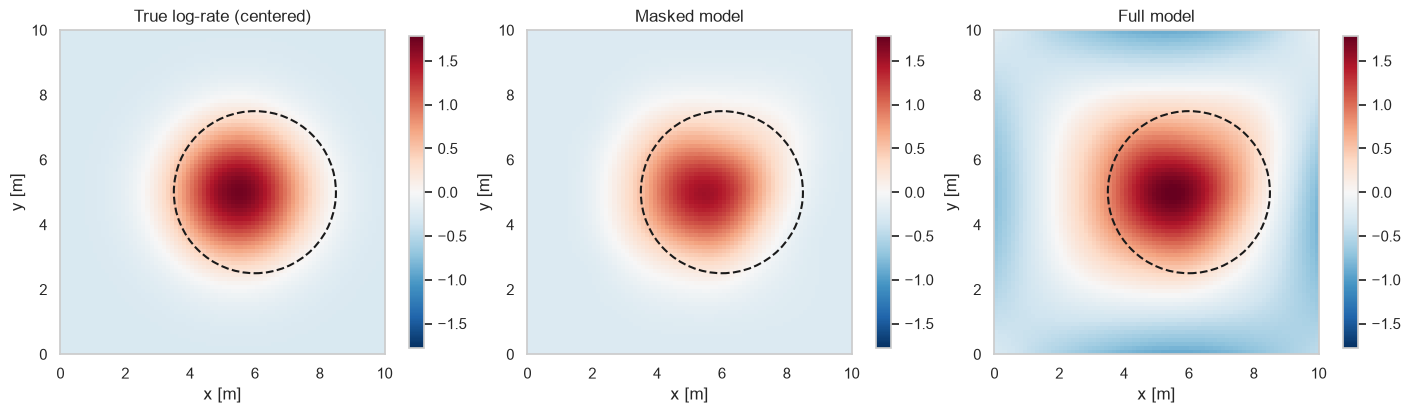

In [11]:
true_log_rate_map = true_log_rate(x_grid, y_grid)
centered_true_map = true_log_rate_map - true_log_rate_map.mean()

smooth_maps = [centered_true_map, smooth_masked_map, smooth_full_map]
smooth_titles = ["True log-rate (centered)", "Masked model", "Full model"]

limit = max(np.abs(values).max() for values in smooth_maps)
image_kwargs = dict(
    origin="lower",
    extent=[0, SQUARE, 0, SQUARE],
    cmap="RdBu_r",
    vmin=-limit,
    vmax=limit,
    aspect="equal",
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True)

for ax, values, title in zip(axes, smooth_maps, smooth_titles):
    image = ax.imshow(values, **image_kwargs)
    ax.add_patch(Circle(ISLAND_CENTER, ISLAND_RADIUS, fill=False, color="k", lw=1.5, ls="--"))
    ax.set(title=title, xlabel="x [m]", ylabel="y [m]")
    ax.grid(False)
    fig.colorbar(image, ax=ax, shrink=0.8)

The two fitted panels agree closely inside the island. They differ outside it.

Retained basis functions can extend beyond the island. Where all retained
basis functions are zero, the masked smooth is constant after centering.
The full model retains coefficients that the data do not directly constrain.
The penalty determines their values and hence the surface in the corners.

Both surfaces are unsupported by data outside the island.

## 6. Predicted firing-rate map

`smooth_compute` returns a centered smooth, which is useful for comparing tuning
shapes across neurons. `predict` instead returns the expected spike count per
sample, with the intercept included. We again run both models.

In [ ]:
predicted_masked = np.asarray(gam_masked.predict((x_flat, y_flat)))
predicted_full = np.asarray(gam_full.predict((x_flat, y_flat)))

masked_count_map = predicted_masked.reshape(GRID_N, GRID_N)
full_count_map = predicted_full.reshape(GRID_N, GRID_N)
true_count_map = np.exp(true_log_rate_map)

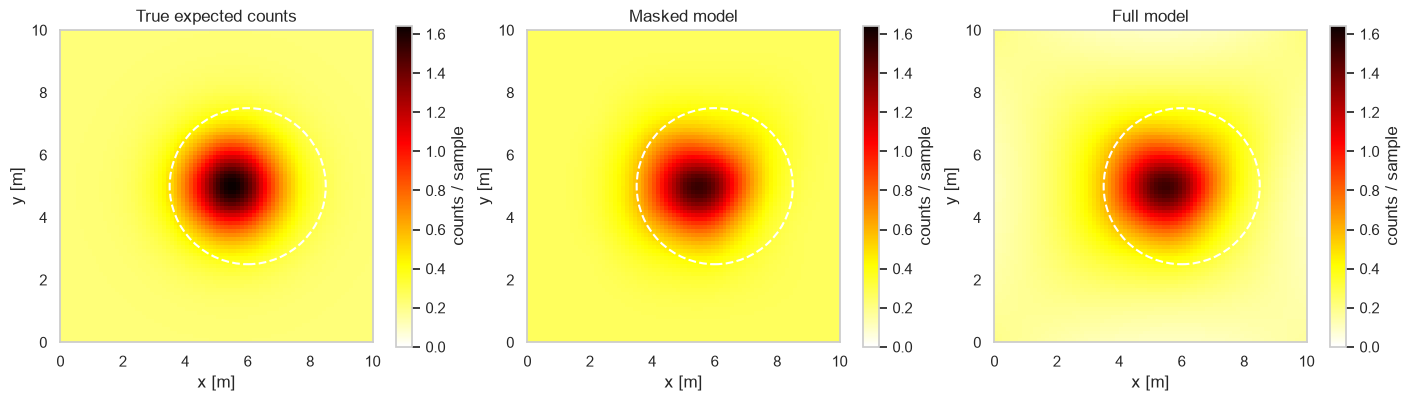

In [13]:
count_maps = [true_count_map, masked_count_map, full_count_map]
count_titles = ["True expected counts", "Masked model", "Full model"]

image_kwargs = dict(
    origin="lower",
    extent=[0, SQUARE, 0, SQUARE],
    cmap="hot_r",
    vmin=0.0,
    vmax=max(values.max() for values in count_maps),
    aspect="equal",
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True)

for ax, values, title in zip(axes, count_maps, count_titles):
    image = ax.imshow(values, **image_kwargs)
    ax.add_patch(Circle(ISLAND_CENTER, ISLAND_RADIUS, fill=False, color="w", lw=1.5, ls="--"))
    ax.set(title=title, xlabel="x [m]", ylabel="y [m]")
    ax.grid(False)
    fig.colorbar(image, ax=ax, shrink=0.8, label="counts / sample")

Inside the island both predictions track the truth. On this scale the two models
look almost the same, because the exponential link squeezes the corner
differences that the log-rate figure showed.

How good is the fit inside the visited region, and how far apart are the two
models there?

In [14]:
distance_to_center = np.hypot(x_grid - ISLAND_CENTER[0], y_grid - ISLAND_CENTER[1])
inside_island = distance_to_center <= ISLAND_RADIUS


def rmse_inside(values):
    """Root mean squared error against the true counts, inside the island."""
    error = values[inside_island] - true_count_map[inside_island]
    return float(np.sqrt(np.mean(error**2)))


largest_gap = np.abs(masked_count_map - full_count_map)[inside_island].max()

print(f"RMSE inside the island, masked model : {rmse_inside(masked_count_map):.4f}")
print(f"RMSE inside the island, full model   : {rmse_inside(full_count_map):.4f}")
print(f"Largest gap between the two models   : {largest_gap:.4f}")

RMSE inside the island, masked model : 0.0528
RMSE inside the island, full model   : 0.0551
Largest gap between the two models   : 0.0387


## 7. Summary

The numbers to report to a collaborator.

In [15]:
print("=== Basis reduction ===")
print(f"  Full basis          : {n_columns:4d} columns")
print(f"  Kept after masking  : {n_active:4d} columns " f"({100 * n_active / n_columns:.0f} % of full)")
print(f"  Reduction factor    : {n_columns / n_active:.1f}x")
print(f"  Fitted coefficients : {gam_full.coef_.size} without masking, " f"{gam_masked.coef_.size} with masking")

=== Basis reduction ===
  Full basis          :  289 columns
  Kept after masking  :  111 columns (38 % of full)
  Reduction factor    : 2.6x
  Fitted coefficients : 288 without masking, 110 with masking


The masked fit recovers the tuning function inside the visited region and
extrapolates outside it. No extra code is needed at prediction time, because
`predict` and `smooth_compute` apply the mask themselves.